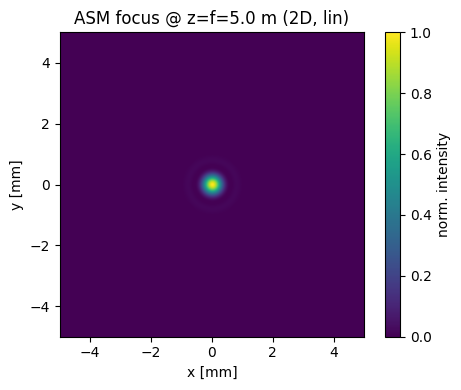

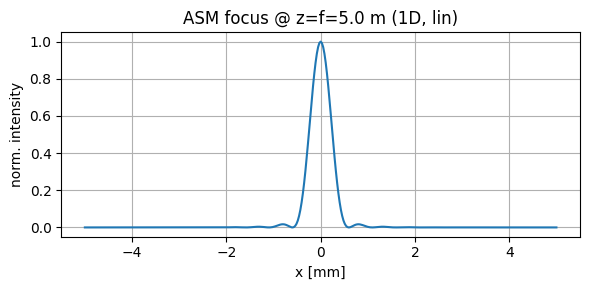

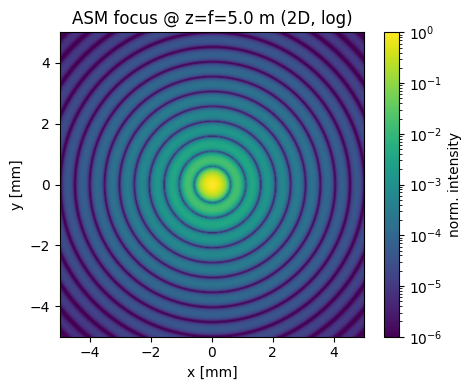

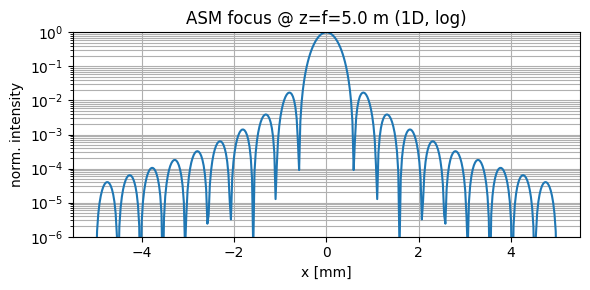

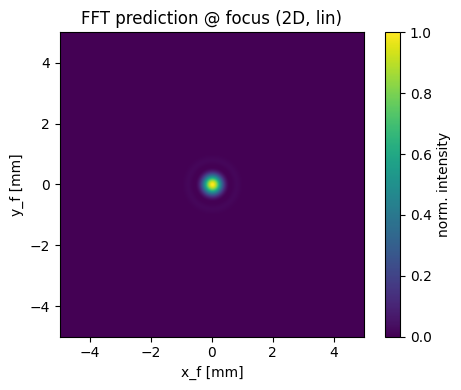

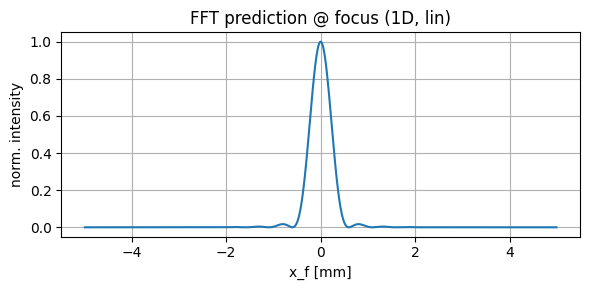

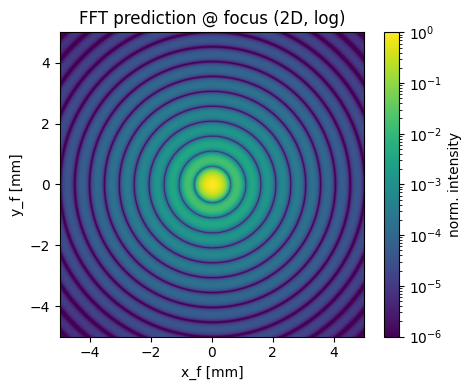

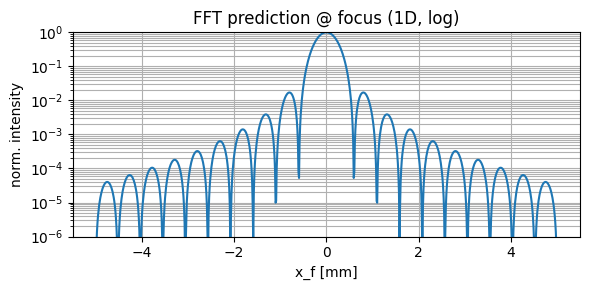

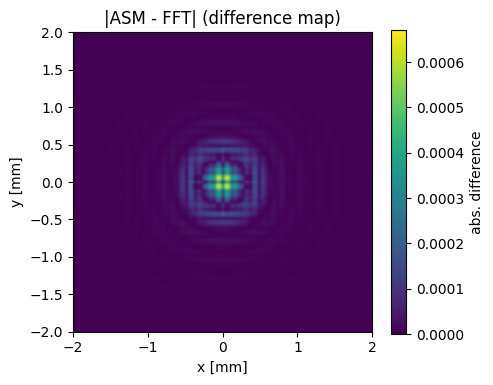

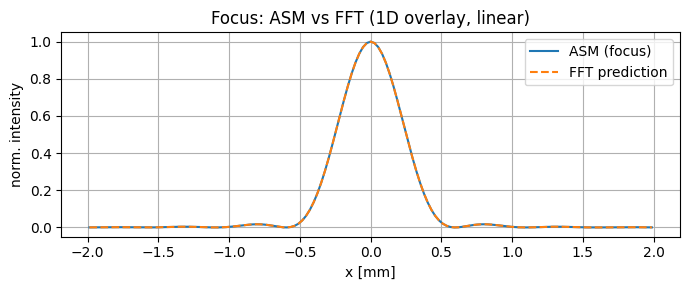

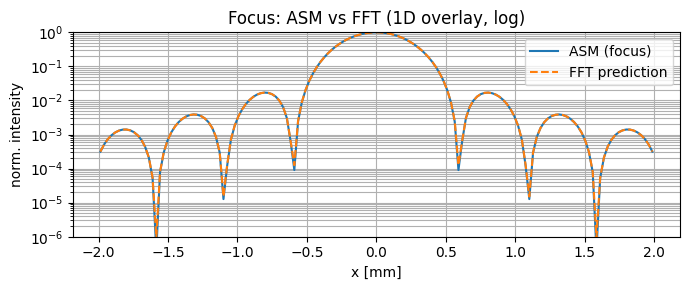

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ==============================================================
# 1) Physics & grid
# ==============================================================
lam = 1064e-9            # wavelength [m]
BEAM_DIAM = 11e-3        # beam diameter [m]

N = 2*1024
L = 5 * BEAM_DIAM
dx = L / N
x = (np.arange(N) - N/2) * dx
y = x
X, Y = np.meshgrid(x, y)

# ==============================================================
# 2) Input field: Super-Gaussian
# ==============================================================
def make_supergauss(n=40):
    w0 = BEAM_DIAM / 2
    R = np.sqrt(X**2 + Y**2)
    return np.exp(-(R / w0)**n).astype(complex)

# ==============================================================
# 3) Thin lens phase mask (lens at z = 0)
# ==============================================================
def apply_thin_lens(U, f):
    k = 2*np.pi / lam
    return U * np.exp(-1j * k * (X**2 + Y**2) / (2 * f))

# ==============================================================
# 4) Angular Spectrum propagation
# ==============================================================
def propagate_asm(U0, z):
    k = 2*np.pi / lam
    fx = np.fft.fftfreq(N, d=dx)
    fy = np.fft.fftfreq(N, d=dx)
    FX, FY = np.meshgrid(fx, fy)

    kx = 2*np.pi * FX
    ky = 2*np.pi * FY
    kz = np.sqrt(k**2 - kx**2 - ky**2 + 0j)

    H = np.exp(1j * kz * z)

    U_k = np.fft.fft2(U0)
    Uz = np.fft.ifft2(U_k * H)
    return Uz

# ==============================================================
# 5) Plot helper: ONE figure per plane
#    Left = 2D, Right = 1D (center cut)
# ==============================================================
def plot_2d_left_1d_right(U, title="", zoom_mm=10.0, log=False):
    I = np.abs(U)**2
    I /= I.max() if I.max() != 0 else 1.0

    x_mm = x * 1e3
    m = np.abs(x_mm) <= zoom_mm

    # ---------- 2D ----------
    I2 = I[np.ix_(m, m)]
    extent = [-zoom_mm, zoom_mm, -zoom_mm, zoom_mm]

    plt.figure(figsize=(5,4))
    if log:
        plt.imshow(I2, extent=extent, origin="lower", aspect="equal",
                   norm=LogNorm(vmin=1e-6, vmax=1), interpolation="bicubic")
        plt.title(title + " (2D, log)")
    else:
        plt.imshow(I2, extent=extent, origin="lower", aspect="equal",
                   interpolation="bicubic")
        plt.title(title + " (2D, lin)")

    plt.xlabel("x [mm]")
    plt.ylabel("y [mm]")
    plt.colorbar(label="norm. intensity")
    plt.tight_layout()
    plt.show()

    # ---------- 1D ----------
    mid = N // 2
    I1 = I[mid, :][m]
    x1 = x_mm[m]

    plt.figure(figsize=(6,3))
    plt.plot(x1, I1)

    if log:
        plt.yscale("log")
        plt.ylim(1e-6, 1)
        plt.title(title + " (1D, log)")
    else:
        plt.title(title + " (1D, lin)")

    plt.xlabel("x [mm]")
    plt.ylabel("norm. intensity")
    plt.grid(True, which="both")
    plt.tight_layout()
    plt.show()


def predict_focus_fft(U_in, f, pad_factor=8):
    """
    Predict focal-plane intensity of an ideal thin lens:
      I_focus(xf,yf) ∝ |FFT{U_in(x,y)}|^2
    with coordinate mapping: xf = lam * f * fx.

    Returns:
      I_pred (2D, normalized)
      x_f_mm (1D axis in mm matching I_pred)
    """
    M = pad_factor * N

    # center U_in in a larger zero-padded array
    U_pad = np.zeros((M, M), dtype=complex)
    s = (M - N) // 2
    U_pad[s:s+N, s:s+N] = U_in

    # centered FFT
    U_F = np.fft.fftshift(np.fft.fft2(U_pad))
    I_pred = np.abs(U_F)**2
    I_pred /= I_pred.max() if I_pred.max() != 0 else 1.0

    # frequency axis -> focal plane axis
    fx = np.fft.fftshift(np.fft.fftfreq(M, d=dx))  # [1/m]
    x_f = (lam * f) * fx                            # [m]
    x_f_mm = x_f * 1e3

    return I_pred, x_f_mm

def plot_pred_focus(I_pred, x_f_mm, title="", zoom_mm=2.0, log=False):
    # crop
    m = np.abs(x_f_mm) <= zoom_mm
    I = I_pred[np.ix_(m, m)]
    extent = [-zoom_mm, zoom_mm, -zoom_mm, zoom_mm]

    # 2D
    plt.figure(figsize=(5,4))
    if log:
        plt.imshow(I, extent=extent, origin="lower",
                   norm=LogNorm(vmin=1e-6, vmax=1), aspect="equal")
    else:
        plt.imshow(I, extent=extent, origin="lower", aspect="equal")
    plt.xlabel("x_f [mm]")
    plt.ylabel("y_f [mm]")
    plt.title(title)
    plt.colorbar(label="norm. intensity")
    plt.tight_layout()
    plt.show()

    # 1D center cut
    mid = I_pred.shape[0] // 2
    I1d = I_pred[mid, :]
    plt.figure(figsize=(6,3))
    plt.plot(x_f_mm[m], I1d[m])
    if log:
        plt.yscale("log")
        plt.ylim(1e-6, 1)
    plt.xlabel("x_f [mm]")
    plt.ylabel("norm. intensity")
    plt.title(title.replace("2D", "1D"))
    plt.grid(True, which="both")
    plt.tight_layout()
    plt.show()

def difference_map_2d(U_focus, I_pred, x_f_mm, zoom_mm=2.0):
    """
    Computes |ASM - FFT| difference map in the focus plane.
    FFT prediction is resampled onto ASM grid in the cropped window.
    """
    I_asm = np.abs(U_focus)**2
    I_asm /= I_asm.max() if I_asm.max() != 0 else 1.0

    x_mm = x * 1e3
    m = np.abs(x_mm) <= zoom_mm

    # crop ASM
    I_asm_c = I_asm[np.ix_(m, m)]
    x_c = x_mm[m]

    # crop FFT on its own axis first
    mf = np.abs(x_f_mm) <= zoom_mm
    I_fft_c = I_pred[np.ix_(mf, mf)]
    x_f_c = x_f_mm[mf]

    # resample FFT -> ASM grid (separable interp, no scipy)
    tmp = np.empty((I_fft_c.shape[0], x_c.size), dtype=float)
    for i in range(I_fft_c.shape[0]):
        tmp[i, :] = np.interp(x_c, x_f_c, I_fft_c[i, :], left=0.0, right=0.0)

    I_fft_on_asm = np.empty((x_c.size, x_c.size), dtype=float)
    for j in range(x_c.size):
        I_fft_on_asm[:, j] = np.interp(x_c, x_f_c, tmp[:, j], left=0.0, right=0.0)

    # normalize again
    I_fft_on_asm /= I_fft_on_asm.max() if I_fft_on_asm.max() != 0 else 1.0

    diff = np.abs(I_asm_c - I_fft_on_asm)

    extent = [-zoom_mm, zoom_mm, -zoom_mm, zoom_mm]
    plt.figure(figsize=(5,4))
    plt.imshow(diff, extent=extent, origin="lower", aspect="equal", interpolation="bicubic")
    plt.xlabel("x [mm]")
    plt.ylabel("y [mm]")
    plt.title("|ASM - FFT| (difference map)")
    plt.colorbar(label="abs. difference")
    plt.tight_layout()
    plt.show()


def overlay_focus_1d(U_focus, I_pred, x_f_mm, zoom_mm=2.0, log=False, title=""):
    """
    Overlay of 1D center cuts (ASM focus vs FFT prediction) on the SAME x-axis.
    FFT is interpolated onto the ASM x-grid.
    """
    # ASM 1D (center cut)
    I_asm = np.abs(U_focus)**2
    I_asm /= I_asm.max() if I_asm.max() != 0 else 1.0
    mid = N // 2
    I_asm_1d = I_asm[mid, :]
    x_mm = x * 1e3

    # FFT 1D (center cut) on its own focal-plane axis
    midp = I_pred.shape[0] // 2
    I_fft_1d = I_pred[midp, :]  # already normalized

    # Interpolate FFT profile onto ASM x-axis
    I_fft_on_asm = np.interp(x_mm, x_f_mm, I_fft_1d, left=0.0, right=0.0)

    # Crop
    m = np.abs(x_mm) <= zoom_mm
    x_plot = x_mm[m]

    plt.figure(figsize=(7,3))
    plt.plot(x_plot, I_asm_1d[m], label="ASM (focus)")
    plt.plot(x_plot, I_fft_on_asm[m], "--", label="FFT prediction")

    if log:
        plt.yscale("log")
        plt.ylim(1e-6, 1)

    plt.xlabel("x [mm]")
    plt.ylabel("norm. intensity")
    plt.title(title if title else ("1D overlay (log)" if log else "1D overlay (lin)"))
    plt.grid(True, which="both")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ==============================================================
# 6) Main: planes z = 0, 4.5, f, 2f
#    For each plane: one "lin" figure and one "log" figure,
#    each with left=2D and right=1D.
# ==============================================================
if __name__ == "__main__":

    f = 5.0  # Brennweite [m]

    # Startfeld (vor Linse)
    U0 = make_supergauss(n=40)

    # Linse bei z=0
    U_after_lens = apply_thin_lens(U0, f)

    # Simulation: Fokus bei z=f
    U_focus = propagate_asm(U_after_lens, f)

    # --- Vorhersage: Fourier-Transformierte von U0 ---
    I_pred, x_f_mm = predict_focus_fft(U0, f, pad_factor=8)

    # --- Plots: ASM Fokus ---
    plot_2d_left_1d_right(U_focus, title=f"ASM focus @ z=f={f} m", zoom_mm=5.0, log=False)
    plot_2d_left_1d_right(U_focus, title=f"ASM focus @ z=f={f} m", zoom_mm=5.0, log=True)


    # --- Plots: FFT Prediction Fokus ---
    plot_pred_focus(I_pred, x_f_mm, title=f"FFT prediction @ focus (2D, lin)", zoom_mm=5.0, log=False)
    plot_pred_focus(I_pred, x_f_mm, title=f"FFT prediction @ focus (2D, log)", zoom_mm=5.0, log=True)
    difference_map_2d(U_focus, I_pred, x_f_mm, zoom_mm=2.0)
    overlay_focus_1d(U_focus, I_pred, x_f_mm, zoom_mm=2.0, log=False,
                 title="Focus: ASM vs FFT (1D overlay, linear)")
    overlay_focus_1d(U_focus, I_pred, x_f_mm, zoom_mm=2.0, log=True,
                 title="Focus: ASM vs FFT (1D overlay, log)")


